# Logical Fallacy Detection - Progress 2
**Dataset:** CoCoLoFa (Comments with Common Logical Fallacies)
https://github.com/Crowd-AI-Lab/cocolofa

**Progress 2:** Baseline model (Logistic Regression) using two text representations:
- **TF-IDF** (Term Frequency-Inverse Document Frequency)
- **Word2Vec** (Word embeddings averaged per document)

**Citation:**
Min-Hsuan Yeh, Ruyuan Wan, and Ting-Hao 'Kenneth' Huang. (2024). *CoCoLoFa: A Dataset of News Comments with Common Logical Fallacies Written by LLM-Assisted Crowds*. [arXiv:2410.03457](https://arxiv.org/abs/2410.03457)

## 0. Import Libraries

In [1]:
import json
import re
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_fscore_support
)
from gensim.models import Word2Vec

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

In [2]:
KAGGLE_PATH = '/kaggle/input/datasets/aristelcrowley/cocolofa'

if os.path.exists(KAGGLE_PATH):
    DATA_DIR = KAGGLE_PATH
    print(f"Running on Kaggle (dataset: {DATA_DIR})")
else:
    DATA_DIR = 'data'   
    print("Running locally")

# Load train data
file_path = os.path.join(DATA_DIR, 'train.json')
with open(file_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    
records = []
for article in raw_data:
    for comment in article['comments']:
        records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df = pd.DataFrame(records)

# Load test data
with open(os.path.join(DATA_DIR, 'test.json'), 'r', encoding='utf-8') as f:
    test_raw = json.load(f)

test_records = []
for article in test_raw:
    for comment in article['comments']:
        test_records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df_test = pd.DataFrame(test_records)

print(f"Total train comments: {len(df)}")
print(f"Total test comments: {len(df_test)}")
print(f"\nDistribusi label fallacy (train):")
print(df['fallacy'].value_counts())
print(f"\n--- Sample Data (Raw Text) ---")
display(df.head(10))

Running locally
Total train comments: 5370
Total test comments: 798

Distribusi label fallacy (train):
fallacy
none                        2202
slippery slope               431
appeal to worse problems     421
appeal to nature             412
appeal to tradition          401
false dilemma                391
appeal to majority           383
hasty generalization         379
appeal to authority          350
Name: count, dtype: int64

--- Sample Data (Raw Text) ---


,comment_id,news_id,fallacy,comment
0,5584,262,none,Lack of transparency in government isn't unexp...
1,5582,262,appeal to authority,While the issues discussed here should be addr...
2,5583,262,none,The excuse that Brazilian municipalities do no...
3,6183,262,none,This is what's to be expected of developing an...
4,6182,262,appeal to tradition,"Sad to say, I have to agree with you. Rulers c..."
5,6184,262,none,Why doesn't the Brazilian federal government s...
6,6782,262,appeal to worse problems,At least they have a set up for it. In some co...
7,6783,262,hasty generalization,If these people can't even manage doing someth...
8,6784,262,appeal to tradition,I completely agree with you! There have alway...
9,10082,262,slippery slope,The argument that people should have access to...


## 2. Text Cleaning

In [3]:
def clean_text(text):
    """Clean raw text."""
    text = text.lower()                                    # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)           # remove URLs
    text = re.sub(r'<[^>]+>', '', text)                    # remove HTML tags
    text = re.sub(r'@\w+', '', text)                       # remove mentions
    text = re.sub(r'#\w+', '', text)                       # remove hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)                # remove numbers & special chars
    text = re.sub(r'\s+', ' ', text).strip()               # remove excess whitespace
    return text

df['cleaned'] = df['comment'].apply(clean_text)
df_test['cleaned'] = df_test['comment'].apply(clean_text)

print("--- Examples Before & After Cleaning ---")
for i in range(3):
    print(f"\n[BEFORE]: {df['comment'].iloc[i][:120]}...")
    print(f"[AFTER ]: {df['cleaned'].iloc[i][:120]}...")

--- Examples Before & After Cleaning ---

[BEFORE]: Lack of transparency in government isn't unexpected.  No one likes to be under scrutiny,  especially not those with powe...
[AFTER ]: lack of transparency in government isnt unexpected no one likes to be under scrutiny especially not those with power tra...

[BEFORE]: While the issues discussed here should be addressed, there need to be priorities. The authorities of the country probabl...
[AFTER ]: while the issues discussed here should be addressed there need to be priorities the authorities of the country probably ...

[BEFORE]: The excuse that Brazilian municipalities do not have the funds to handle the public service requests does not hold water...
[AFTER ]: the excuse that brazilian municipalities do not have the funds to handle the public service requests does not hold water...


## 3. Tokenization

In [4]:
df['tokens'] = df['cleaned'].apply(word_tokenize)
df_test['tokens'] = df_test['cleaned'].apply(word_tokenize)

print("--- Tokenization Results ---")
for i in range(3):
    print(f"\n[CLEANED ]: {df['cleaned'].iloc[i][:100]}...")
    print(f"[TOKENS  ]: {df['tokens'].iloc[i][:15]}...")
    print(f"Token count: {len(df['tokens'].iloc[i])}")

--- Tokenization Results ---

[CLEANED ]: lack of transparency in government isnt unexpected no one likes to be under scrutiny especially not ...
[TOKENS  ]: ['lack', 'of', 'transparency', 'in', 'government', 'isnt', 'unexpected', 'no', 'one', 'likes', 'to', 'be', 'under', 'scrutiny', 'especially']...
Token count: 64

[CLEANED ]: while the issues discussed here should be addressed there need to be priorities the authorities of t...
[TOKENS  ]: ['while', 'the', 'issues', 'discussed', 'here', 'should', 'be', 'addressed', 'there', 'need', 'to', 'be', 'priorities', 'the', 'authorities']...
Token count: 55

[CLEANED ]: the excuse that brazilian municipalities do not have the funds to handle the public service requests...
[TOKENS  ]: ['the', 'excuse', 'that', 'brazilian', 'municipalities', 'do', 'not', 'have', 'the', 'funds', 'to', 'handle', 'the', 'public', 'service']...
Token count: 93


## 4. Stopword Removal & Lemmatization

> **Lemmatization** is chosen over stemming because it produces linguistically valid base words, more suitable for fallacy detection tasks that require semantic understanding.

In [5]:
# Words that are NLTK stopwords but are KEY fallacy indicators — we keep these
fallacy_indicators = {
    'everyone', 'always', 'never', 'must', 'should', 'all', 'every',
    'only', 'just', 'no', 'nothing', 'everything', 'most', 'any',
    'either', 'or', 'neither', 'nor', 'both', 'very', 'too',
}
stop_words = set(stopwords.words('english')) - fallacy_indicators
print(f"Stopwords: {len(set(stopwords.words('english')))} total → {len(stop_words)} after keeping {len(fallacy_indicators)} fallacy indicators")

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """Remove stopwords (except fallacy indicators) and lemmatize each token."""
    return [
        lemmatizer.lemmatize(token)
        for token in tokens
        if (token not in stop_words and len(token) > 2) or token in fallacy_indicators
    ]

df['lemmatized'] = df['tokens'].apply(lemmatize_tokens)
df_test['lemmatized'] = df_test['tokens'].apply(lemmatize_tokens)

# Rejoin into string for TF-IDF
df['processed_text'] = df['lemmatized'].apply(lambda x: ' '.join(x))
df_test['processed_text'] = df_test['lemmatized'].apply(lambda x: ' '.join(x))

print("\n--- Lemmatization Results ---")
for i in range(3):
    print(f"\n[TOKENS     ]: {df['tokens'].iloc[i][:12]}...")
    print(f"[LEMMATIZED ]: {df['lemmatized'].iloc[i][:12]}...")
    print(f"Token count before: {len(df['tokens'].iloc[i])} → after: {len(df['lemmatized'].iloc[i])}")

Stopwords: 198 total → 186 after keeping 21 fallacy indicators

--- Lemmatization Results ---

[TOKENS     ]: ['lack', 'of', 'transparency', 'in', 'government', 'isnt', 'unexpected', 'no', 'one', 'likes', 'to', 'be']...
[LEMMATIZED ]: ['lack', 'transparency', 'government', 'isnt', 'unexpected', 'no', 'one', 'like', 'scrutiny', 'especially', 'power', 'transparency']...
Token count before: 64 → after: 33

[TOKENS     ]: ['while', 'the', 'issues', 'discussed', 'here', 'should', 'be', 'addressed', 'there', 'need', 'to', 'be']...
[LEMMATIZED ]: ['issue', 'discussed', 'should', 'addressed', 'need', 'priority', 'authority', 'country', 'probably', 'know', 'whats', 'important']...
Token count before: 55 → after: 31

[TOKENS     ]: ['the', 'excuse', 'that', 'brazilian', 'municipalities', 'do', 'not', 'have', 'the', 'funds', 'to', 'handle']...
[LEMMATIZED ]: ['excuse', 'brazilian', 'municipality', 'fund', 'handle', 'public', 'service', 'request', 'hold', 'water', 'evident', 'fact']...
Token count

## 5. Label Encoding

In [6]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['fallacy'])
df_test['label'] = label_encoder.transform(df_test['fallacy'])

print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i} → {cls} ({count} samples)")

Number of classes: 9

Label mapping:
  0 → appeal to authority (350 samples)
  1 → appeal to majority (383 samples)
  2 → appeal to nature (412 samples)
  3 → appeal to tradition (401 samples)
  4 → appeal to worse problems (421 samples)
  5 → false dilemma (391 samples)
  6 → hasty generalization (379 samples)
  7 → none (2202 samples)
  8 → slippery slope (431 samples)


## 6. Train/Validation/Test Split (80/10/10)

The original dataset provides train.json and test.json. We split the train data into train/validation (roughly 80/10 of total), and use test.json as test set (10%).

In [7]:
df_train, df_val = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df['label']
)

print(f"Train set size: {len(df_train)} ({len(df_train)/(len(df_train)+len(df_val)+len(df_test))*100:.1f}%)")
print(f"Validation set size: {len(df_val)} ({len(df_val)/(len(df_train)+len(df_val)+len(df_test))*100:.1f}%)")
print(f"Test set size: {len(df_test)} ({len(df_test)/(len(df_train)+len(df_val)+len(df_test))*100:.1f}%)")
print(f"\nTotal: {len(df_train)+len(df_val)+len(df_test)}")

Train set size: 4564 (74.0%)
Validation set size: 806 (13.1%)
Test set size: 798 (12.9%)

Total: 6168


---
## 7. Text Representation 

### 7a: TF-IDF

**TF-IDF** measures how important a word is in a document relative to the entire corpus.
- Captures keyword patterns that often appear in each fallacy type.
- Produces a high-dimensional sparse matrix.

In [8]:
# TF-IDF Vectorization — optimized for fallacy detection
tfidf_vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
)

# Fit on train data only
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['processed_text'])
X_val_tfidf = tfidf_vectorizer.transform(df_val['processed_text'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['processed_text'])

print(f"TF-IDF Matrix Shapes:")
print(f"  Train: {X_train_tfidf.shape}")
print(f"  Validation: {X_val_tfidf.shape}")
print(f"  Test: {X_test_tfidf.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample features (unigrams/bigrams/trigrams): {list(feature_names[:20])}")

TF-IDF Matrix Shapes:
  Train: (4564, 8000)
  Validation: (806, 8000)
  Test: (798, 8000)

Sample features (unigrams/bigrams/trigrams): ['abandon', 'abandoned', 'abandonment', 'abhorrent', 'ability', 'ability people', 'able', 'able access', 'able choose', 'able come', 'able continue', 'able express', 'able get', 'able make', 'able say', 'able speak', 'able speak mind', 'able use', 'abnormal', 'abroad']


### 7b: Word2Vec

**Word2Vec** learns vector embeddings for each word based on context.
- Captures semantic relationships between words (e.g., "authority" close to "expert").
- Document representation is obtained by averaging all word vectors in the document.
- Produces a fixed-dimension dense vector for each document.

In [9]:
# Train Word2Vec on train corpus only
w2v_model = Word2Vec(
    sentences=df_train['lemmatized'].tolist(),
    vector_size=100,    # embedding dimension
    window=5,           # context window
    min_count=2,        # ignore words appearing < 2 times
    workers=4,
    epochs=20,
    sg=1                # skip-gram (better for smaller datasets)
)

print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"Vector dimension: {w2v_model.wv.vector_size}")

# Show similar words examples
for word in ['government', 'freedom', 'tradition']:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\nWords similar to '{word}':")
        for w, score in similar:
            print(f"  {w}: {score:.4f}")

Vocabulary size: 6180
Vector dimension: 100

Words similar to 'government':
  illegally: 0.6195
  overreaching: 0.6037
  accordingly: 0.5942
  silence: 0.5932
  federal: 0.5922

Words similar to 'freedom':
  expression: 0.7392
  speech: 0.6599
  stripped: 0.6211
  infringed: 0.6167
  inviolate: 0.6126

Words similar to 'tradition':
  globalization: 0.5585
  deity: 0.5524
  adopting: 0.5252
  habit: 0.5215
  deeprooted: 0.5190


In [10]:
def document_vector(tokens, model):
    """Calculate average Word2Vec vector for all tokens in a document."""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

# Create document vectors for all sets
X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in df_train['lemmatized']])
X_val_w2v = np.array([document_vector(tokens, w2v_model) for tokens in df_val['lemmatized']])
X_test_w2v = np.array([document_vector(tokens, w2v_model) for tokens in df_test['lemmatized']])

print(f"Word2Vec Document Matrix Shapes:")
print(f"  Train: {X_train_w2v.shape}")
print(f"  Validation: {X_val_w2v.shape}")
print(f"  Test: {X_test_w2v.shape}")

Word2Vec Document Matrix Shapes:
  Train: (4564, 100)
  Validation: (806, 100)
  Test: (798, 100)


In [11]:
# Prepare labels
y_train = df_train['label'].values
y_val = df_val['label'].values
y_test = df_test['label'].values

---
## 8. Model Training: Logistic Regression

### 8a. Logistic Regression + TF-IDF

In [12]:
# Train Logistic Regression with TF-IDF
model_logreg_tfidf = LogisticRegression(
    max_iter=1000,
    C=1.5,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs',
    n_jobs=-1
)

print("Training Logistic Regression with TF-IDF...")
model_logreg_tfidf.fit(X_train_tfidf, y_train)
print("Training complete!")

# Evaluate
y_train_pred = model_logreg_tfidf.predict(X_train_tfidf)
y_val_pred = model_logreg_tfidf.predict(X_val_tfidf)

train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\nLogistic Regression + TF-IDF:")
print(f"  Train - Accuracy: {train_acc:.4f}, F1: {train_f1:.4f}")
print(f"  Val   - Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}")

Training Logistic Regression with TF-IDF...
Training complete!

Logistic Regression + TF-IDF:
  Train - Accuracy: 0.8777, F1: 0.8740
  Val   - Accuracy: 0.6576, F1: 0.6582


### 8b. Logistic Regression + Word2Vec

In [13]:
# Train Logistic Regression with Word2Vec
model_logreg_w2v = LogisticRegression(
    max_iter=1000,
    C=1.5,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs',
    n_jobs=-1
)

print("Training Logistic Regression with Word2Vec...")
model_logreg_w2v.fit(X_train_w2v, y_train)
print("Training complete!")

# Evaluate
y_train_pred_w2v = model_logreg_w2v.predict(X_train_w2v)
y_val_pred_w2v = model_logreg_w2v.predict(X_val_w2v)

train_acc_w2v = accuracy_score(y_train, y_train_pred_w2v)
train_f1_w2v = f1_score(y_train, y_train_pred_w2v, average='weighted')
val_acc_w2v = accuracy_score(y_val, y_val_pred_w2v)
val_f1_w2v = f1_score(y_val, y_val_pred_w2v, average='weighted')

print(f"\nLogistic Regression + Word2Vec:")
print(f"  Train - Accuracy: {train_acc_w2v:.4f}, F1: {train_f1_w2v:.4f}")
print(f"  Val   - Accuracy: {val_acc_w2v:.4f}, F1: {val_f1_w2v:.4f}")

Training Logistic Regression with Word2Vec...
Training complete!

Logistic Regression + Word2Vec:
  Train - Accuracy: 0.5383, F1: 0.5094
  Val   - Accuracy: 0.5124, F1: 0.4915


---
## 9. Test Evaluation

In [14]:
# Test evaluation - TF-IDF
y_test_pred_tfidf = model_logreg_tfidf.predict(X_test_tfidf)

test_acc_tfidf = accuracy_score(y_test, y_test_pred_tfidf)
test_f1_weighted_tfidf = f1_score(y_test, y_test_pred_tfidf, average='weighted')
test_f1_macro_tfidf = f1_score(y_test, y_test_pred_tfidf, average='macro')
test_precision_tfidf = precision_score(y_test, y_test_pred_tfidf, average='weighted')
test_recall_tfidf = recall_score(y_test, y_test_pred_tfidf, average='weighted')

print("  LOGISTIC REGRESSION + TF-IDF — Test Results")
print(f"Accuracy: {test_acc_tfidf:.4f}")
print(f"Precision (weighted): {test_precision_tfidf:.4f}")
print(f"Recall (weighted): {test_recall_tfidf:.4f}")
print(f"F1 (weighted): {test_f1_weighted_tfidf:.4f}")
print(f"F1 (macro): {test_f1_macro_tfidf:.4f}")
print("\n" + classification_report(y_test, y_test_pred_tfidf, target_names=label_encoder.classes_))

  LOGISTIC REGRESSION + TF-IDF — Test Results
Accuracy: 0.6855
Precision (weighted): 0.6889
Recall (weighted): 0.6855
F1 (weighted): 0.6830
F1 (macro): 0.6979

                          precision    recall  f1-score   support

     appeal to authority       0.63      0.64      0.64        56
      appeal to majority       0.73      0.86      0.79        59
        appeal to nature       0.84      0.93      0.88        55
     appeal to tradition       0.65      0.78      0.71        59
appeal to worse problems       0.70      0.77      0.73        64
           false dilemma       0.69      0.82      0.75        50
    hasty generalization       0.40      0.43      0.42        60
                    none       0.73      0.60      0.66       317
          slippery slope       0.68      0.74      0.71        78

                accuracy                           0.69       798
               macro avg       0.67      0.73      0.70       798
            weighted avg       0.69      0.69 

In [15]:
# Test evaluation - Word2Vec
y_test_pred_w2v = model_logreg_w2v.predict(X_test_w2v)

test_acc_w2v = accuracy_score(y_test, y_test_pred_w2v)
test_f1_weighted_w2v = f1_score(y_test, y_test_pred_w2v, average='weighted')
test_f1_macro_w2v = f1_score(y_test, y_test_pred_w2v, average='macro')
test_precision_w2v = precision_score(y_test, y_test_pred_w2v, average='weighted')
test_recall_w2v = recall_score(y_test, y_test_pred_w2v, average='weighted')

print("  LOGISTIC REGRESSION + WORD2VEC — Test Results")
print(f"Accuracy: {test_acc_w2v:.4f}")
print(f"Precision (weighted): {test_precision_w2v:.4f}")
print(f"Recall (weighted): {test_recall_w2v:.4f}")
print(f"F1 (weighted): {test_f1_weighted_w2v:.4f}")
print(f"F1 (macro): {test_f1_macro_w2v:.4f}")
print("\n" + classification_report(y_test, y_test_pred_w2v, target_names=label_encoder.classes_))

  LOGISTIC REGRESSION + WORD2VEC — Test Results
Accuracy: 0.5263
Precision (weighted): 0.5722
Recall (weighted): 0.5263
F1 (weighted): 0.5165
F1 (macro): 0.5623

                          precision    recall  f1-score   support

     appeal to authority       0.40      0.61      0.49        56
      appeal to majority       0.53      0.69      0.60        59
        appeal to nature       0.67      0.82      0.74        55
     appeal to tradition       0.51      0.75      0.60        59
appeal to worse problems       0.67      0.75      0.71        64
           false dilemma       0.59      0.76      0.67        50
    hasty generalization       0.19      0.32      0.24        60
                    none       0.66      0.31      0.42       317
          slippery slope       0.55      0.68      0.61        78

                accuracy                           0.53       798
               macro avg       0.53      0.63      0.56       798
            weighted avg       0.57      0.5

---
## 10. Model Comparison

In [16]:
# Create comparison table
comparison_data = {
    'Model': ['Logistic Regression', 'Logistic Regression'],
    'Text Representation': ['TF-IDF', 'Word2Vec'],
    'Accuracy': [test_acc_tfidf, test_acc_w2v],
    'Precision': [test_precision_tfidf, test_precision_w2v],
    'Recall': [test_recall_tfidf, test_recall_w2v],
    'F1 (weighted)': [test_f1_weighted_tfidf, test_f1_weighted_w2v],
    'F1 (macro)': [test_f1_macro_tfidf, test_f1_macro_w2v]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
comparison_df.index += 1

print("  PROGRESS 2 — Model Comparison (Ranked by Weighted F1)")
display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 (weighted)': '{:.4f}',
    'F1 (macro)': '{:.4f}',
}).background_gradient(subset=['F1 (weighted)'], cmap='Greens'))

  PROGRESS 2 — Model Comparison (Ranked by Weighted F1)


,Model,Text Representation,Accuracy,Precision,Recall,F1 (weighted),F1 (macro)
1,Logistic Regression,TF-IDF,0.6855,0.6889,0.6855,0.6830,0.6979
2,Logistic Regression,Word2Vec,0.5263,0.5722,0.5263,0.5165,0.5623


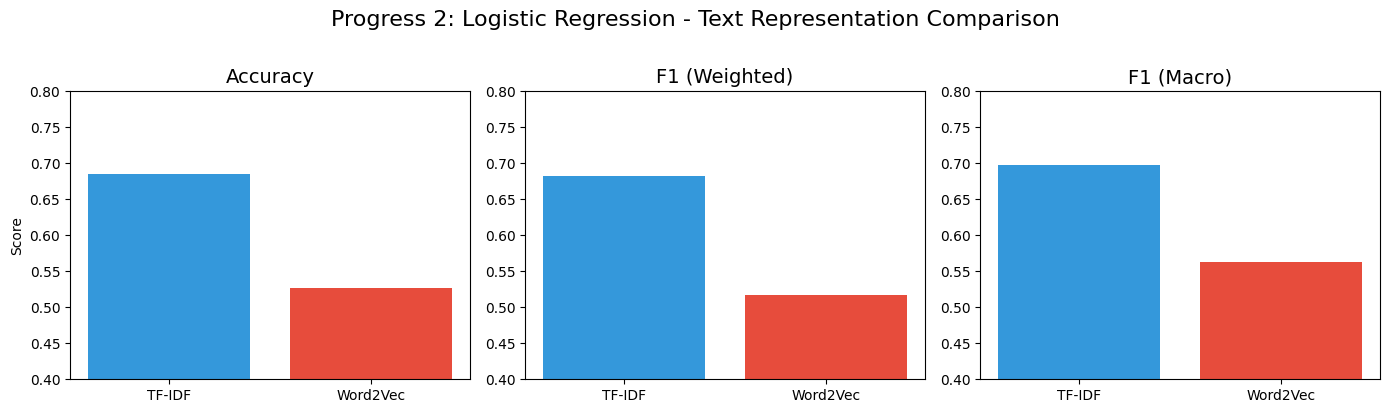

In [17]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

representations = ['TF-IDF', 'Word2Vec']
colors = ['#3498db', '#e74c3c']

# Accuracy
axes[0].bar(representations, [test_acc_tfidf, test_acc_w2v], color=colors)
axes[0].set_title('Accuracy', fontsize=14)
axes[0].set_ylim(0.4, 0.8)
axes[0].set_ylabel('Score')

# F1 Weighted
axes[1].bar(representations, [test_f1_weighted_tfidf, test_f1_weighted_w2v], color=colors)
axes[1].set_title('F1 (Weighted)', fontsize=14)
axes[1].set_ylim(0.4, 0.8)

# F1 Macro
axes[2].bar(representations, [test_f1_macro_tfidf, test_f1_macro_w2v], color=colors)
axes[2].set_title('F1 (Macro)', fontsize=14)
axes[2].set_ylim(0.4, 0.8)

plt.suptitle('Progress 2: Logistic Regression - Text Representation Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 11. Per-Class F1 Score Analysis (Best Model)

In [ ]:
# Use the best performing model for per-class analysis
if test_f1_weighted_tfidf >= test_f1_weighted_w2v:
    best_pred = y_test_pred_tfidf
    best_repr = 'TF-IDF'
else:
    best_pred = y_test_pred_w2v
    best_repr = 'Word2Vec'

precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_test, best_pred, average=None
)

per_class_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Support': support
}).sort_values('F1-Score', ascending=False)

print(f"  PER-CLASS F1 SCORES (Best Model: LogReg + {best_repr})")
display(per_class_df.style.format({
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'Support': '{:.0f}'
}).background_gradient(subset=['F1-Score'], cmap='Greens'))

  PER-CLASS F1 SCORES (Best Model: LogReg + Word2Vec)


,Class,Precision,Recall,F1-Score,Support
2,appeal to nature,0.8361,0.9273,0.8793,55
1,appeal to majority,0.7286,0.8644,0.7907,59
5,false dilemma,0.6949,0.8200,0.7523,50
4,appeal to worse problems,0.7000,0.7656,0.7313,64
8,slippery slope,0.6824,0.7436,0.7117,78
3,appeal to tradition,0.6479,0.7797,0.7077,59
7,none,0.7269,0.5962,0.6551,317
0,appeal to authority,0.6316,0.6429,0.6372,56
6,hasty generalization,0.4000,0.4333,0.4160,60


## 12. Confusion Matrix

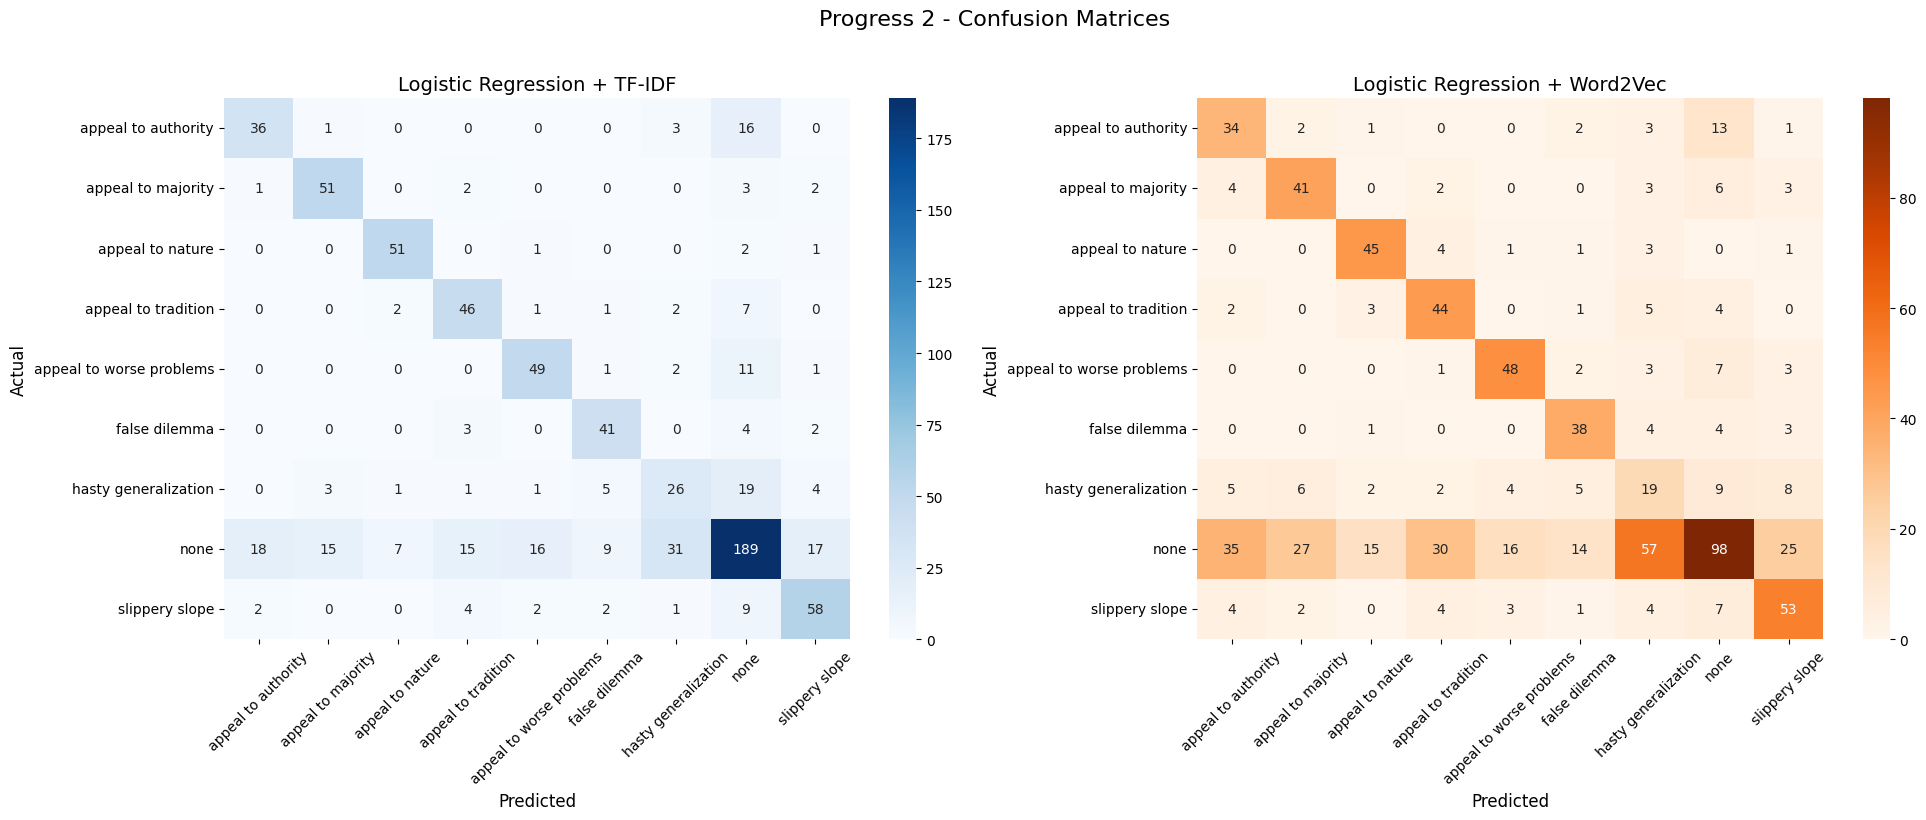

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# TF-IDF Confusion Matrix
cm_tfidf = confusion_matrix(y_test, y_test_pred_tfidf)
sns.heatmap(
    cm_tfidf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
axes[0].set_title('Logistic Regression + TF-IDF', fontsize=14)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Word2Vec Confusion Matrix
cm_w2v = confusion_matrix(y_test, y_test_pred_w2v)
sns.heatmap(
    cm_w2v, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
axes[1].set_title('Logistic Regression + Word2Vec', fontsize=14)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Progress 2 - Confusion Matrices', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 13. Save Models

In [20]:
# Create models directory if it doesn't exist
os.makedirs('models/progress_2', exist_ok=True)

# Save both models
joblib.dump(model_logreg_tfidf, 'models/progress_2/logistic_regression_tfidf.joblib')
joblib.dump(model_logreg_w2v, 'models/progress_2/logistic_regression_w2v.joblib')

# Save vectorizers and encoders
joblib.dump(tfidf_vectorizer, 'models/progress_2/tfidf_vectorizer.joblib')
joblib.dump(w2v_model, 'models/progress_2/word2vec_model.joblib')
joblib.dump(label_encoder, 'models/progress_2/label_encoder.joblib')

# Save preprocessing info and results
preprocessing_info = {
    'fallacy_indicators': list(fallacy_indicators),
    'models': {
        'logreg_tfidf': {
            'accuracy': test_acc_tfidf,
            'f1_weighted': test_f1_weighted_tfidf,
            'f1_macro': test_f1_macro_tfidf
        },
        'logreg_w2v': {
            'accuracy': test_acc_w2v,
            'f1_weighted': test_f1_weighted_w2v,
            'f1_macro': test_f1_macro_w2v
        }
    }
}
joblib.dump(preprocessing_info, 'models/progress_2/preprocessing_info.joblib')

print("All models saved to models/progress_2/")
print("\nSaved files:")
for f in os.listdir('models/progress_2'):
    print(f"  - {f}")

All models saved to models/progress_2/

Saved files:
  - label_encoder.joblib
  - logistic_regression_tfidf.joblib
  - logistic_regression_w2v.joblib
  - preprocessing_info.joblib
  - tfidf_vectorizer.joblib
  - word2vec_model.joblib


## 14. Summary

In [21]:
print("  PROGRESS 2 SUMMARY")
print(f"\nModel: Logistic Regression")
print(f"\nText Representations:")
print(f"  1. TF-IDF (max_features=8000, ngram_range=(1,3))")
print(f"  2. Word2Vec (vector_size=100, window=5, skip-gram)")
print(f"\nData Split:")
print(f"  Train: {len(df_train)} samples")
print(f"  Validation: {len(df_val)} samples")
print(f"  Test: {len(df_test)} samples")
print(f"\nTest Results:")
print(f"  LogReg + TF-IDF   → Acc: {test_acc_tfidf:.4f}, F1: {test_f1_weighted_tfidf:.4f}")
print(f"  LogReg + Word2Vec → Acc: {test_acc_w2v:.4f}, F1: {test_f1_weighted_w2v:.4f}")
print(f"\nBest: Logistic Regression + {best_repr}")
print(f"\nModels saved to: models/progress_2/")

  PROGRESS 2 SUMMARY

Model: Logistic Regression

Text Representations:
  1. TF-IDF (max_features=8000, ngram_range=(1,3))
  2. Word2Vec (vector_size=100, window=5, skip-gram)

Data Split:
  Train: 4564 samples
  Validation: 806 samples
  Test: 798 samples

Test Results:
  LogReg + TF-IDF   → Acc: 0.6855, F1: 0.6830
  LogReg + Word2Vec → Acc: 0.5263, F1: 0.5165

Best: Logistic Regression + TF-IDF

Models saved to: models/progress_2/


---
## 15. Inference (Single Input)

This cell loads the saved model and performs inference on a single new input.

In [22]:
# Local Inference - Load saved model and predict on new input
import joblib
import re
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Choose representation: 'tfidf' or 'w2v'
use_representation = 'tfidf'  # Change to 'w2v' to use Word2Vec model

# Load saved models based on choice
if use_representation == 'tfidf':
    loaded_model = joblib.load('models/progress_2/logistic_regression_tfidf.joblib')
    loaded_vectorizer = joblib.load('models/progress_2/tfidf_vectorizer.joblib')
else:
    loaded_model = joblib.load('models/progress_2/logistic_regression_w2v.joblib')
    loaded_w2v = joblib.load('models/progress_2/word2vec_model.joblib')

loaded_label_encoder = joblib.load('models/progress_2/label_encoder.joblib')
loaded_info = joblib.load('models/progress_2/preprocessing_info.joblib')

# Preprocessing functions
def clean_text_inference(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

fallacy_indicators_loaded = set(loaded_info['fallacy_indicators'])
stop_words_loaded = set(stopwords.words('english')) - fallacy_indicators_loaded
lemmatizer_loaded = WordNetLemmatizer()

def preprocess_text_inference(text):
    cleaned = clean_text_inference(text)
    tokens = word_tokenize(cleaned)
    lemmatized = [
        lemmatizer_loaded.lemmatize(token)
        for token in tokens
        if (token not in stop_words_loaded and len(token) > 2) or token in fallacy_indicators_loaded
    ]
    return lemmatized, ' '.join(lemmatized)

def document_vector_inference(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

def predict_fallacy(text):
    """Predict the fallacy type for a single text input."""
    tokens, processed_text = preprocess_text_inference(text)
    
    if use_representation == 'tfidf':
        features = loaded_vectorizer.transform([processed_text])
    else:
        vec = document_vector_inference(tokens, loaded_w2v)
        features = vec.reshape(1, -1)
    
    prediction = loaded_model.predict(features)[0]
    probabilities = loaded_model.predict_proba(features)[0]
    
    predicted_label = loaded_label_encoder.inverse_transform([prediction])[0]
    confidence = probabilities[prediction]
    
    return predicted_label, confidence, dict(zip(loaded_label_encoder.classes_, probabilities))

# Example inference
test_input = "Everyone knows that this is true. All experts agree with this opinion."

print("  LOCAL INFERENCE")
print(f"\nInput text: {test_input}")
print(f"\nUsing: Logistic Regression + {use_representation.upper()}")

predicted_label, confidence, all_probs = predict_fallacy(test_input)

print(f"\nPredicted Fallacy: {predicted_label}")
print(f"Confidence: {confidence:.4f}")
print(f"\nAll class probabilities:")
for cls, prob in sorted(all_probs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {cls}: {prob:.4f}")

  LOCAL INFERENCE

Input text: Everyone knows that this is true. All experts agree with this opinion.

Using: Logistic Regression + TFIDF

Predicted Fallacy: appeal to authority
Confidence: 0.9013

All class probabilities:
  appeal to authority: 0.9013
  appeal to majority: 0.0798
  hasty generalization: 0.0056
  none: 0.0038
  slippery slope: 0.0023
  appeal to tradition: 0.0021
  appeal to nature: 0.0020
  false dilemma: 0.0017
  appeal to worse problems: 0.0014
